# AERO 331 Final Exam
---
*Created by Henry Flushman*

---
## Imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from libFRC_v1_1 import Laminate

---
## Material Properties

### Problem 1

In [7]:
E1 = 140e9
E2 = 10e9
G12 = 7e9
nu12 = 0.3

Xt = 2.0e9      # Sigma11 (tensile)
Xc = 1.1e9      # Sigma11 (compress)
Yt = 0.08e9     # Sigma22 (tensile)
Yc = 0.28e9     # Sigma22 (compress)
S12 = 0.12e9    # Tau12 shear

---
## Geometries

### Problem 1

In [8]:
Lx = 0.1        # m
Ly = 0.1        # m
tTotal = 0.01   # m

---
## Helper Functions

In [9]:
def BuildLayup(theta):
    """
    var:
        theta - Angle of varying ply [deg]
    returns:
        Full layup of laminate
    """
    return [30.0, -30.0, 45.0, theta, 45.0, -30.0, 30.0]

def LocalStressFromGlobal(ply, sigma):
    return ply.Ts() @ sigma

def MapToBottomHalf(plyNumber):
    if plyNumber <= 4:
        return plyNumber
    return 8 - plyNumber

def FailureScaleForLocalStress(sigma):
    s1, s2, t12 = sigma
    candidates = []
    
    # Fiber Direction
    if abs(s1) > 1e-14:
        if s1 > 0:
            candidates.append((Xt / s1, "sigma_1_tension"))
        else:
            candidates.append((-Xc / s1, "sigma_1_compression"))
    
    # Transverse Direction
    if abs(s2) > 1e-14:
        if s2 > 0:
            candidates.append((Yt / s2, "sigma_2_tension"))
        else:
            candidates.append((-Yc / s2, "sigma_2_compression"))
            
    # In plane
    if abs(t12) > 1e-14:
        candidates.append((S12 / abs(t12), "tau_12"))
        
    candidates = [c for c in candidates if c[0] > 0]
    
    return min(candidates, key=lambda x: x[0])

def ThetaAnalysis(theta):
    layup = BuildLayup(theta)
    
    lam = Laminate(
        theta=layup,
        t=tTotal,
        E1=E1,
        E2=E2,
        nu12=nu12,
        G12=G12
    )
    
    # Pure bending
    NM = np.array([0.0, 0.0, 0.0, 1.0, 0.0, 0.0])
    solution = np.linalg.solve(lam.ABD, NM)
    
    eps0 = solution[:3]
    kappa = solution[3:]
    
    bestScale = np.inf
    bestInfo = None
    
    for i, ply in enumerate(lam.ply):
        plyNum = i + 1
        
        for z, face in [(ply.zL, "bottom"), (ply.zH, "top")]:
            epsGlobal = eps0 - z * kappa
            sigGlobal = ply.Qbar @ epsGlobal
            sigLocal = LocalStressFromGlobal(ply, sigGlobal)
            
            scale, mode = FailureScaleForLocalStress(sigLocal)
            
            if scale < bestScale:
                bestScale = scale
                bestInfo = {
                    "plyNumber": plyNum,
                    "plyBottom": MapToBottomHalf(plyNum),
                    "face": face,
                    "z": z,
                    "mode": mode,
                    "sigLocal": sigLocal,
                    "eps0": eps0,
                    "kappa": kappa,
                    "ABD": lam.ABD.copy(),
                    "layup": layup
                }
                
    return bestScale, bestInfo["plyBottom"], bestInfo["mode"], bestInfo["face"], bestInfo



---
## Analysis

### Problem 1


Results Table
------------------------------------------------------------------------------------------
theta (deg) |     MxFail (N) |  Total edge moment (N*m) | Fail ply |  Mode
------------------------------------------------------------------------------------------
         0 |       7939.325 |                  793.933 |        1 | tau_12            
         5 |       7934.058 |                  793.406 |        1 | tau_12            
        10 |       7925.860 |                  792.586 |        1 | tau_12            
        15 |       7915.916 |                  791.592 |        1 | tau_12            
        20 |       7905.688 |                  790.569 |        1 | tau_12            
        25 |       7896.728 |                  789.673 |        1 | tau_12            
        30 |       7890.487 |                  789.049 |        1 | tau_12            
        35 |       7888.128 |                  788.813 |        1 | tau_12            
        40 |       7890.371 |   

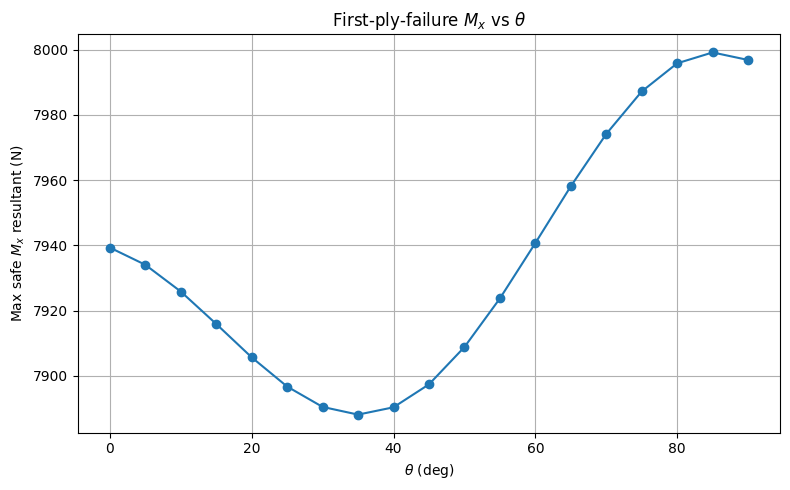

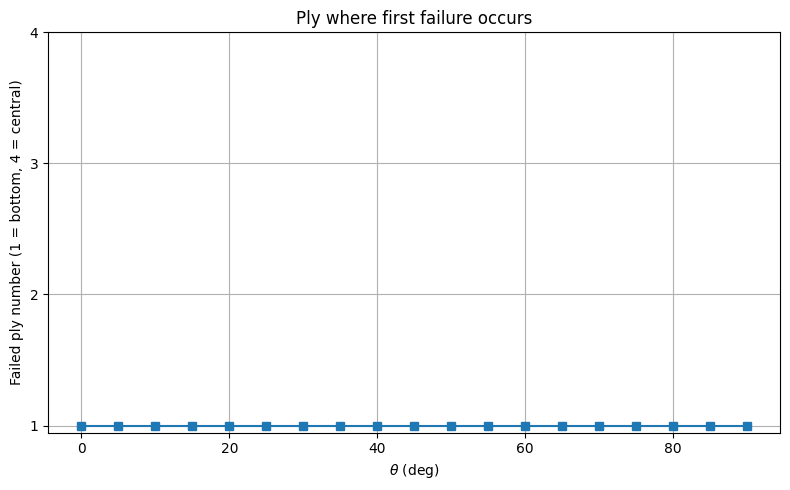

In [10]:
def main():
    thetaValues = np.arange(0, 91, 5)
    
    MxFail = []
    plyFail = []
    modeFail = []
    
    results = []
    
    for theta in thetaValues:
        MxStar, plyStar, modeStar, faceStar, info = ThetaAnalysis(theta)
        
        MxFail.append(MxStar)
        plyFail.append(plyStar)
        modeFail.append(modeStar)
        
        results.append({
            "theta": theta,
            "MxFail": MxStar,
            "MxFail_TotalMoment": MxStar*Ly,
            "plyNum": plyStar,
            "modeFail": modeStar,
            "faceFail": faceStar,
            "layup": info["layup"]
        })
        
    MxFail = np.array(MxFail)
    plyFail = np.array(plyFail)
    
    # Theta selection
    idxBest = np.argmax(MxFail)
    thetaBest = thetaValues[idxBest]
    MxBest = MxFail[idxBest]
    
    print("\nResults Table")
    print("-"*90)
    print(f"{'theta (deg)':>10s} | {'MxFail (N)':>14s} | {'Total edge moment (N*m)':>24s} | {'Fail ply':>8s} | {'Mode':>5s}")
    print("-"*90)
    
    for row in results:
        print(f"{row['theta']:10.0f} | "
              f"{row['MxFail']:14.3f} | "
              f"{row['MxFail_TotalMoment']:24.3f} | "
              f"{row['plyNum']:8d} | "
              f"{row['modeFail']:18s}")
        
    print("\nBest choice of theta based on max safe Mx:")
    print(f"  theta = {thetaBest:.0f} deg")
    print(f"  Mx_fail (resultant) = {MxBest:.3f} N")
    print(f"  Total moment for 10 cm width = {MxBest * Ly:.3f} N*m")
    
    # Plot 1: max safe Mx vs theta
    plt.figure(figsize=(8, 5))
    plt.plot(thetaValues, MxFail, marker='o')
    plt.xlabel(r'$\theta$ (deg)')
    plt.ylabel(r'Max safe $M_x$ resultant (N)')
    plt.title(r'First-ply-failure $M_x$ vs $\theta$')
    plt.grid(True)
    plt.tight_layout()

    # Plot 2: failed ply number vs theta
    plt.figure(figsize=(8, 5))
    plt.plot(thetaValues, plyFail, marker='s')
    plt.xlabel(r'$\theta$ (deg)')
    plt.ylabel('Failed ply number (1 = bottom, 4 = central)')
    plt.title('Ply where first failure occurs')
    plt.yticks([1, 2, 3, 4])
    plt.grid(True)
    plt.tight_layout()

    plt.show()

if __name__ == "__main__":
    main()

---